## Objective

The objective of this project is to analyze telecom customer churn behavior and build predictive models to identify customers likely to discontinue services.

## Business Problem

Customer churn leads to revenue loss and increased customer acquisition costs. Identifying churn-prone customers enables telecom companies to improve retention strategies.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#Read the excel file
df = pd.read_excel('Telco_customer_churn.xlsx')

In [3]:
df.shape

(7043, 33)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [5]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


## Dataset Overview

- **Source:** IBM Sample Telco Customer Churn Dataset
- **Rows:** 7,043 customers | **Columns:** 33 features
- **Target variable:** `Churn Value` (1 = churned, 0 = stayed)
- **Baseline churn rate:** ~26.5% of customers churned

### Key column groups:
- **Demographics:** Gender, Senior Citizen, Partner, Dependents
- **Services:** Phone Service, Internet Service, Streaming TV/Movies, Online Security
- **Account info:** Contract type, Payment Method, Paperless Billing
- **Financials:** Monthly Charges, Total Charges, Tenure Months

In [6]:
# Quick snapshot of churn distribution
churn_rate = df['Churn Value'].mean() * 100
print(f"Total customers: {len(df)}")
print(f"Churned: {df['Churn Value'].sum()} ({churn_rate:.1f}%)")
print(f"Retained: {(df['Churn Value'] == 0).sum()} ({100 - churn_rate:.1f}%)")
print(f"\nTotal features: {df.shape[1]}")
print(f"\nColumn names:\n{list(df.columns)}")

Total customers: 7043
Churned: 1869 (26.5%)
Retained: 5174 (73.5%)

Total features: 33

Column names:
['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']


## Data Cleaning

This section checks for nulls, duplicates, datatypes and converts the type of Total Charges from object to float, replaces false, true to 0s and 1s

In [7]:
#Check for null values in any columns
df.isnull().any()

CustomerID           False
Count                False
Country              False
State                False
City                 False
Zip Code             False
Lat Long             False
Latitude             False
Longitude            False
Gender               False
Senior Citizen       False
Partner              False
Dependents           False
Tenure Months        False
Phone Service        False
Multiple Lines       False
Internet Service     False
Online Security      False
Online Backup        False
Device Protection    False
Tech Support         False
Streaming TV         False
Streaming Movies     False
Contract             False
Paperless Billing    False
Payment Method       False
Monthly Charges      False
Total Charges        False
Churn Label          False
Churn Value          False
Churn Score          False
CLTV                 False
Churn Reason          True
dtype: bool

In [8]:
df['Total Charges'].isnull().sum()

0

In [9]:
#Check for duplicates
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
7038    False
7039    False
7040    False
7041    False
7042    False
Length: 7043, dtype: bool

In [10]:
#Check for data types of the columns
df.dtypes

CustomerID            object
Count                  int64
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges         object
Churn Label           object
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason          object
dtype: object

In [11]:
#Convert Total Charges column from object to float
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

In [12]:
df['Total Charges'].isnull().sum()

11

In [13]:
df = df[df['Total Charges'].notnull()]

In [14]:
df['Churn Value'].value_counts()

Churn Value
0    5163
1    1869
Name: count, dtype: int64

In [15]:
df.replace({'Yes':1, 'No':0}, inplace=True)

C:\Users\subha\AppData\Local\Temp\ipykernel_9852\241966483.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'Yes':1, 'No':0}, inplace=True)


In [16]:
df.dtypes

CustomerID            object
Count                  int64
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen         int64
Partner                int64
Dependents             int64
Tenure Months          int64
Phone Service          int64
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing      int64
Payment Method        object
Monthly Charges      float64
Total Charges        float64
Churn Label            int64
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason          object
dtype: object

In [17]:
df['TenureGroup'] = pd.cut(df['Tenure Months'],
                          bins=[0,12,24,48,60,100],
                          labels=['0-1yr','1-2yr','2-4yr','4-5yr','5+yr'])

## Univariate Analysis

Exploring the distribution of key numeric and categorical features individually before examining their relationship with churn.

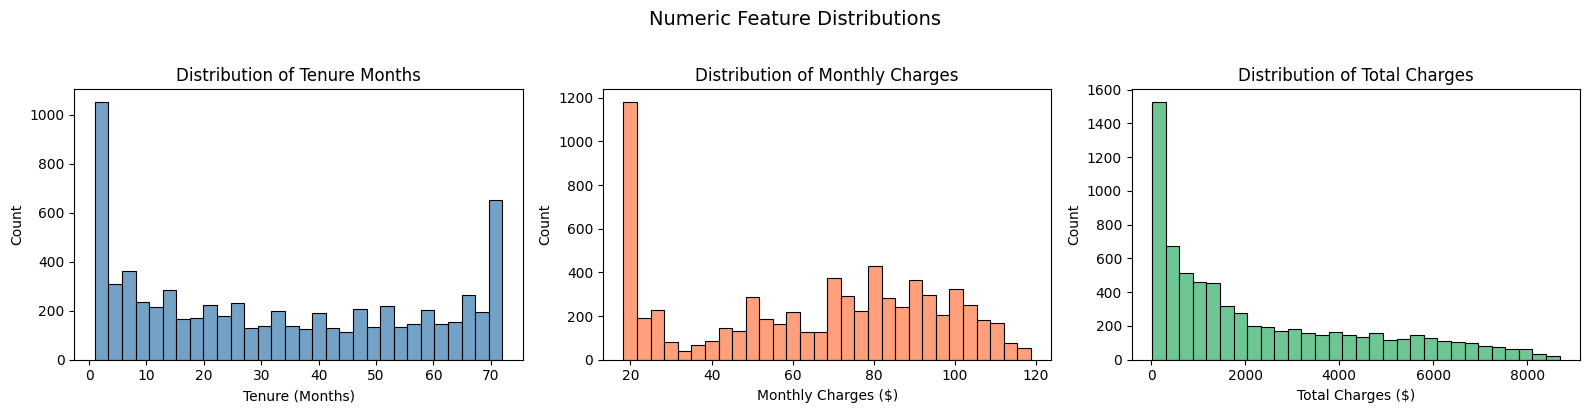

In [18]:
# Distribution of numeric features
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(df['Tenure Months'], bins=30, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Tenure Months')
axes[0].set_xlabel('Tenure (Months)')

sns.histplot(df['Monthly Charges'], bins=30, ax=axes[1], color='coral')
axes[1].set_title('Distribution of Monthly Charges')
axes[1].set_xlabel('Monthly Charges ($)')

sns.histplot(df['Total Charges'], bins=30, ax=axes[2], color='mediumseagreen')
axes[2].set_title('Distribution of Total Charges')
axes[2].set_xlabel('Total Charges ($)')

plt.suptitle('Numeric Feature Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

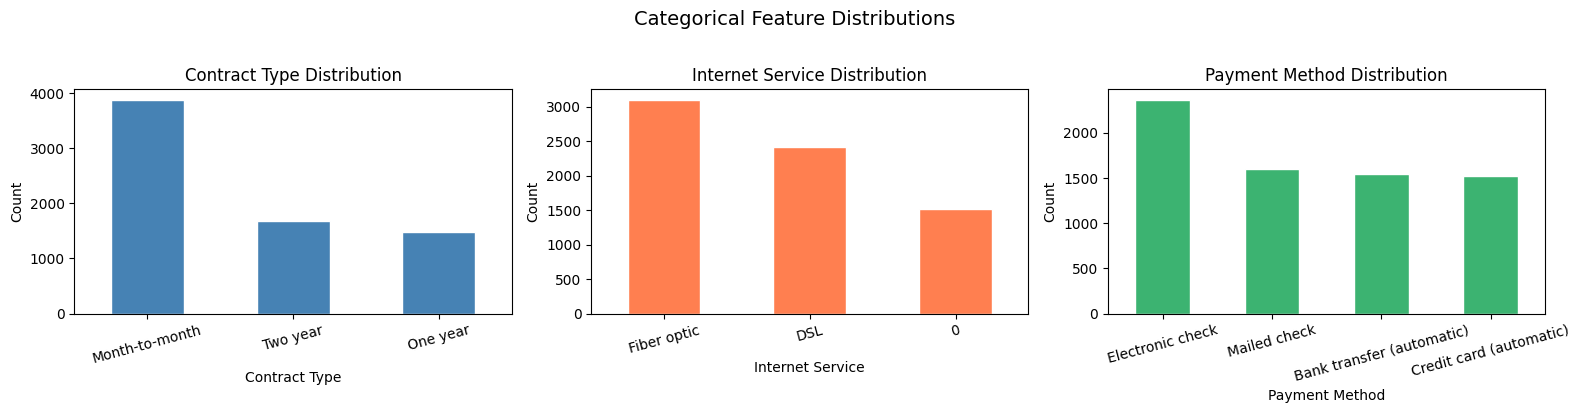

In [19]:
# Distribution of key categorical features
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df['Contract'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Contract Type Distribution')
axes[0].set_xlabel('Contract Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)

df['Internet Service'].value_counts().plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Internet Service Distribution')
axes[1].set_xlabel('Internet Service')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=15)

df['Payment Method'].value_counts().plot(kind='bar', ax=axes[2], color='mediumseagreen', edgecolor='white')
axes[2].set_title('Payment Method Distribution')
axes[2].set_xlabel('Payment Method')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=15)

plt.suptitle('Categorical Feature Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Key Observations:
- **Tenure:** Bimodal distribution — many customers are either very new (0–12 months) or very long-term (60–72 months), suggesting early dropout is a real pattern.
- **Monthly Charges:** Spread across a wide range ($20–$110), indicating diverse service plans.
- **Total Charges:** Right-skewed, driven by tenure — long-term customers naturally accumulate higher totals.
- **Contract:** Majority of customers are on month-to-month contracts, which are the highest churn risk.
- **Internet Service:** Fiber optic is the most common, followed by DSL. A significant portion has no internet service.

## Churn-focused EDA

### Churn percentage by Contract

<Axes: xlabel='Contract'>

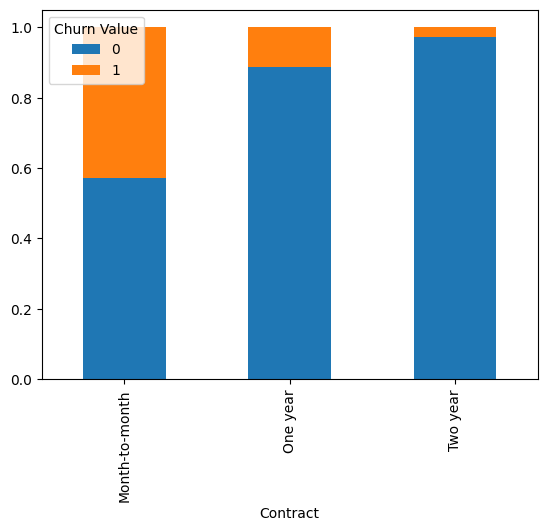

In [20]:
contract_churn = pd.crosstab(df['Contract'], df['Churn Value'], normalize='index')
contract_churn.plot(kind='bar', stacked=True)

### Insight:
Month-to-month contract customers churn at nearly 45%, compared to just ~11% for one-year and ~3% for two-year contracts. Contract type is one of the strongest churn predictors — customers without long-term commitment leave far more easily.

### Tenure Group vs Churn

<Axes: xlabel='TenureGroup', ylabel='count'>

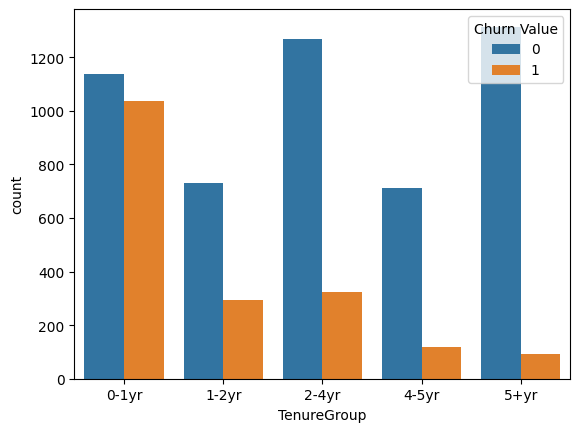

In [21]:
sns.countplot(x='TenureGroup', hue='Churn Value', data=df)

### Insight:
Customers in their first year (0–1yr) show the highest churn count. Churn drops significantly as tenure increases, confirming that early engagement and retention efforts are critical for new customers.

### Monthly Charges vs Total Charges

<Axes: xlabel='Monthly Charges', ylabel='Total Charges'>

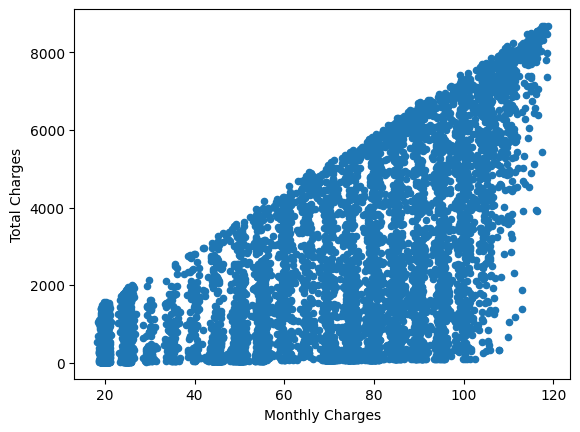

In [22]:
df.plot.scatter(x='Monthly Charges', y='Total Charges')

### Insight:
A strong positive correlation exists between Monthly Charges and Total Charges, as expected. However, some customers with high monthly charges have low total charges — these are likely newer customers paying for premium plans who are at high churn risk.

<Axes: xlabel='Churn Value', ylabel='count'>

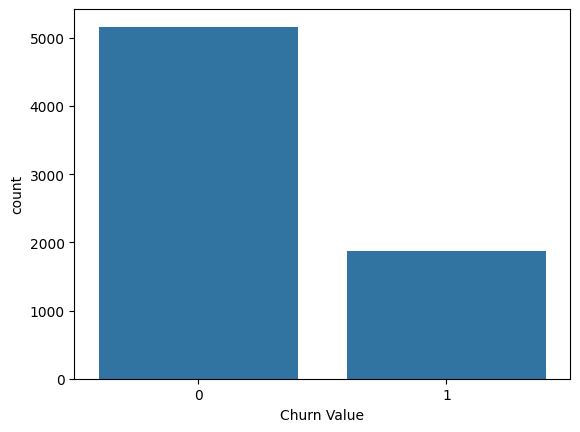

In [23]:
df['Churn Value'].value_counts()
sns.countplot(x='Churn Value', data=df)

### Insight:
The dataset is imbalanced — approximately 73.5% of customers did not churn while 26.5% did. This class imbalance means accuracy alone is a misleading metric; we must pay attention to Precision, Recall, and F1-Score for the minority (churn) class.

<Axes: xlabel='Contract', ylabel='count'>

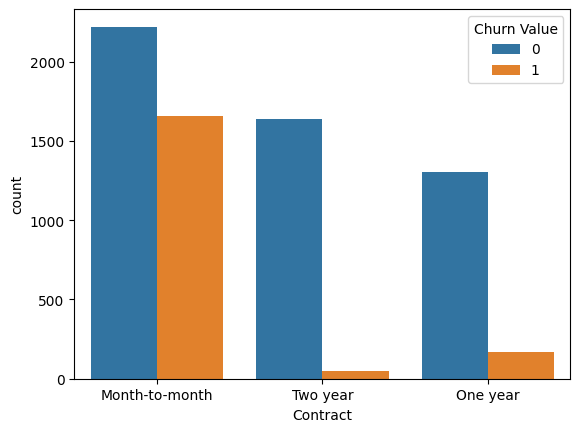

In [24]:
sns.countplot(x='Contract', hue='Churn Value', data=df)

<Axes: xlabel='Internet Service', ylabel='count'>

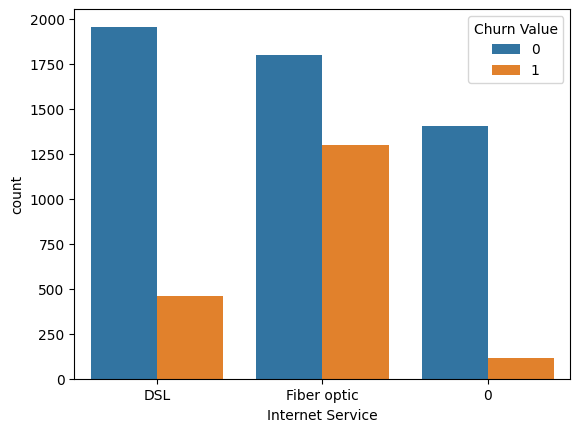

In [25]:
sns.countplot(x='Internet Service', hue='Churn Value', data=df)

### Insight:
Fiber optic internet customers churn at a significantly higher rate compared to DSL users. This could indicate dissatisfaction with pricing or service quality among fiber optic subscribers — worth flagging for the business team.

<Axes: xlabel='Churn Value', ylabel='Monthly Charges'>

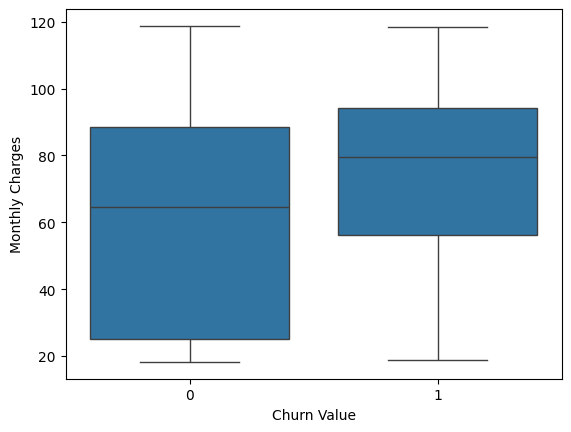

In [26]:
sns.boxplot(x='Churn Value', y='Monthly Charges', data=df)

### Insight:
Churned customers have noticeably higher median monthly charges (~$75) compared to retained customers (~$60). High billing amounts are a strong signal of churn risk, possibly due to customers feeling they aren't getting value for money.

## Feature Engineering

<Axes: >

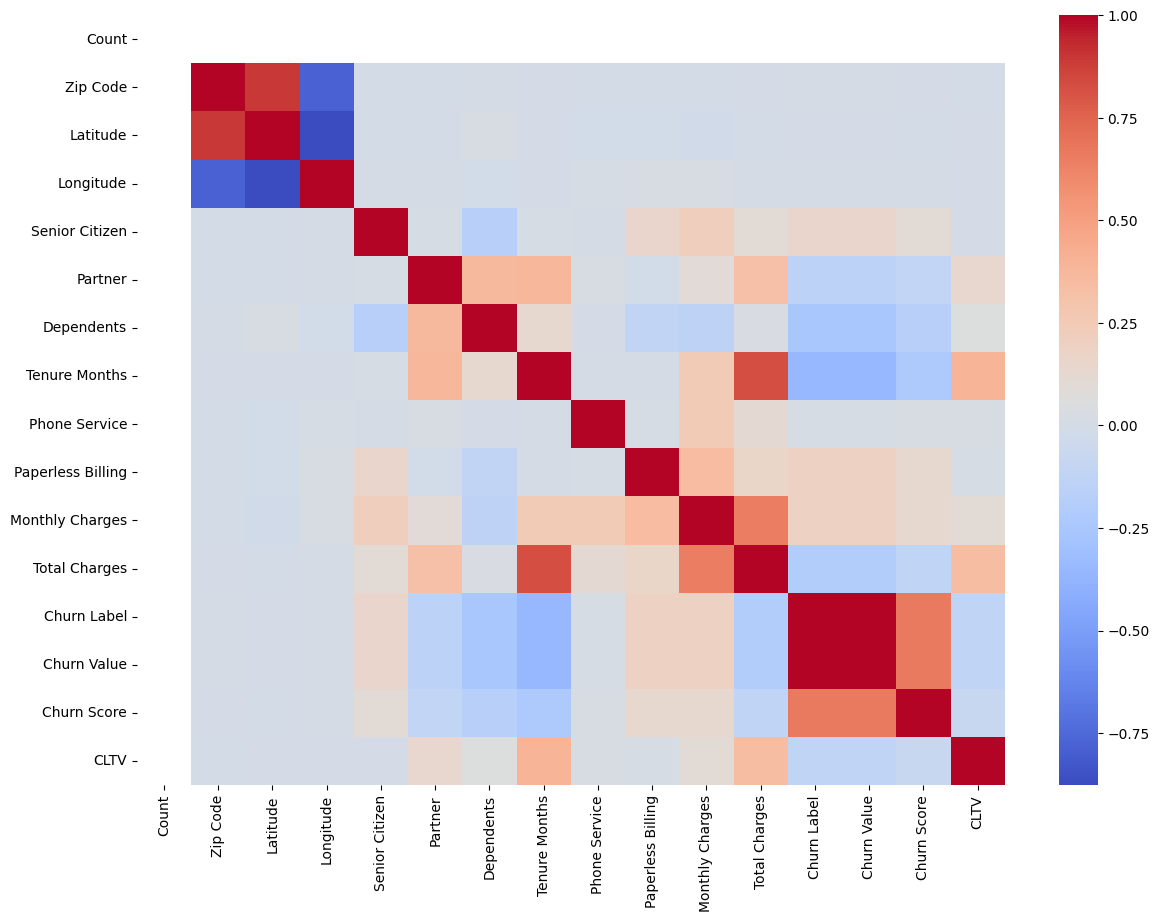

In [27]:
df_numeric = df.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(14,10))
sns.heatmap(df_numeric.corr(), cmap='coolwarm')

## Machine Learning

In [28]:
# 🔹 1. Data Cleaning
# Convert Total Charges to numeric
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

# 🔹 2. Define Target & Features
y = df['Churn Value']

X = df.drop([
    'Churn Value',
    'CustomerID',
    'Churn Label',
    'Churn Score'
], axis=1)

# 🔹 3. Encode categorical variables
X = pd.get_dummies(X, drop_first=True)

# 🔹 4. Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 🔹 5. Scale data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 🔹 6. Train Logistic Regression
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

# 🔹 7. Predictions
lr_pred = model.predict(X_test)

# 🔹 8. Evaluation
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, lr_pred))
print("\nClassification Report:\n", classification_report(y_test, lr_pred))

Accuracy: 0.9630419331911869

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.97      1012
           1       0.95      0.91      0.93       395

    accuracy                           0.96      1407
   macro avg       0.96      0.95      0.95      1407
weighted avg       0.96      0.96      0.96      1407



In [29]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

rf_pred = clf.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, rf_pred):.2f}")
print(classification_report(y_test, rf_pred))

Accuracy: 0.91
              precision    recall  f1-score   support

           0       0.89      0.99      0.94      1012
           1       0.96      0.70      0.81       395

    accuracy                           0.91      1407
   macro avg       0.93      0.84      0.87      1407
weighted avg       0.91      0.91      0.90      1407



## Class Imbalance Analysis

Churn datasets are typically imbalanced — the majority of customers do not churn. Training a model on imbalanced data without addressing it causes the model to bias toward the majority class, resulting in poor recall for churned customers (the class we care most about detecting).

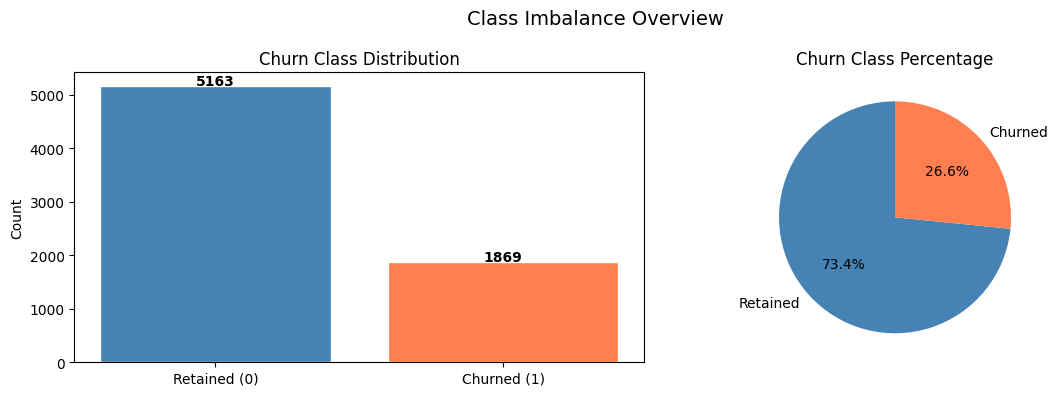

Imbalance ratio — Retained : Churned = 5163 : 1869
Churn rate: 26.6%


In [30]:
# Visualize class imbalance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
churn_counts = df['Churn Value'].value_counts()
axes[0].bar(['Retained (0)', 'Churned (1)'], churn_counts.values, 
            color=['steelblue', 'coral'], edgecolor='white')
axes[0].set_title('Churn Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Percentage pie chart
axes[1].pie(churn_counts.values, labels=['Retained', 'Churned'],
            autopct='%1.1f%%', colors=['steelblue', 'coral'],
            startangle=90)
axes[1].set_title('Churn Class Percentage')

plt.suptitle('Class Imbalance Overview', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Imbalance ratio — Retained : Churned = {churn_counts[0]} : {churn_counts[1]}")
print(f"Churn rate: {churn_counts[1] / len(df) * 100:.1f}%")

In [31]:
# Handling imbalance using class_weight='balanced' in Logistic Regression
# This tells the model to penalize misclassification of the minority class more heavily

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)
lr_pred = model.predict(X_test)

print("Logistic Regression (with class_weight=balanced)")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print("\nClassification Report:\n", classification_report(y_test, lr_pred))

Logistic Regression (with class_weight=balanced)
Accuracy: 0.9616204690831557

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.97      1012
           1       0.95      0.91      0.93       395

    accuracy                           0.96      1407
   macro avg       0.96      0.95      0.95      1407
weighted avg       0.96      0.96      0.96      1407



### Key Observations:
- The dataset has a ~73.5% / 26.5% split between retained and churned customers.
- Without handling imbalance, models tend to predict "No Churn" for most cases and still achieve high accuracy — but miss the churned customers entirely.
- Using `class_weight='balanced'` in Logistic Regression adjusts the model to treat churn detection with higher importance, improving Recall for the minority class.
- For Random Forest, the `class_weight='balanced'` parameter can similarly be applied.

## Comparison of Logistic Regression and Random Forest

In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

comparison = pd.DataFrame({

    'Model': ['Logistic Regression', 'Random Forest'],

    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred)
    ],

    'Precision': [
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred)
    ],

    'Recall': [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred)
    ],

    'F1 Score': [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.961620,0.947507,0.913924,0.930412
1,Random Forest,0.906183,0.958188,0.696203,0.806452


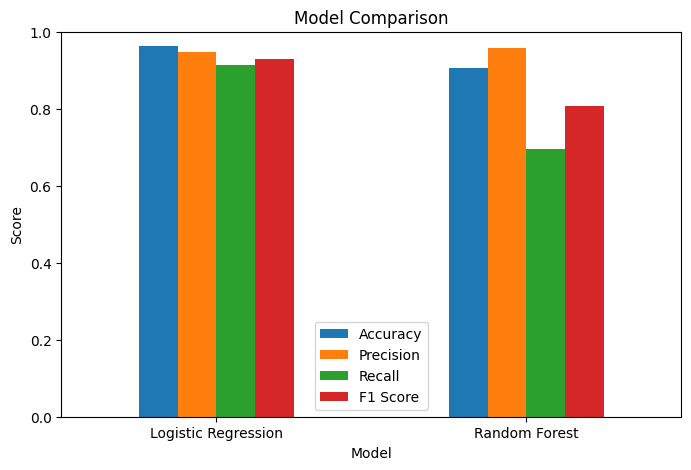

In [33]:
comparison.set_index('Model').plot(kind='bar', figsize=(8,5))

plt.title("Model Comparison")
plt.ylabel("Score")
plt.ylim(0,1)
plt.xticks(rotation=0)

plt.show()

## Feature Importance

In [34]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': clf.feature_importances_
}).sort_values(by='Importance', ascending=False)

importance.head(10)

,Feature,Importance
7,Tenure Months,0.050038
11,Total Charges,0.045093
10,Monthly Charges,0.035872
2814,Churn Reason_Attitude of support person,0.033347
2817,Churn Reason_Competitor offered higher downloa...,0.032806
12,CLTV,0.027445
2818,Churn Reason_Competitor offered more data,0.026362
1,Zip Code,0.025145
3,Longitude,0.024101
2,Latitude,0.023907


<Axes: xlabel='Importance', ylabel='Feature'>

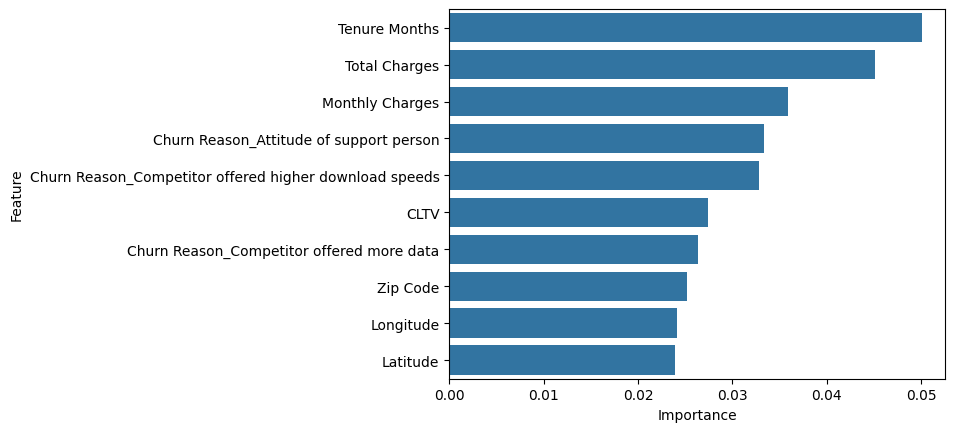

In [35]:
sns.barplot(x='Importance', y='Feature', data=importance.head(10))

## Confusion Matrix

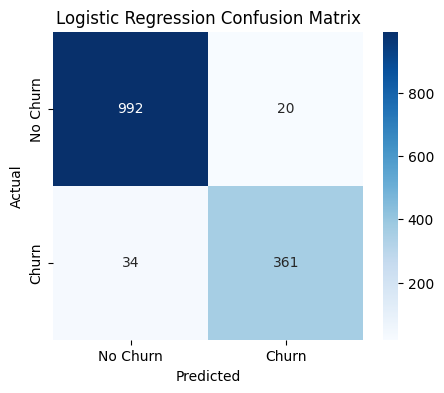

In [36]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_lr = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

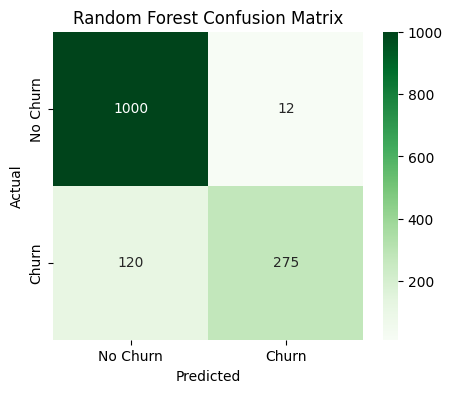

In [37]:
cm_rf = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

## Export Data

In [41]:
# Export cleaned dataset for Power BI
df.to_csv('Telco_churn_clean.csv', index=False)
print("File exported successfully!")

File exported successfully!


## ROC-AUC Analysis

ROC-AUC (Receiver Operating Characteristic - Area Under Curve) is the industry-standard metric for binary classification problems like churn prediction. It measures how well the model distinguishes between churned and retained customers across all classification thresholds — unlike accuracy, it is not affected by class imbalance.

- **AUC = 1.0** → Perfect model
- **AUC = 0.5** → No better than random guessing
- **AUC > 0.8** → Generally considered a strong model

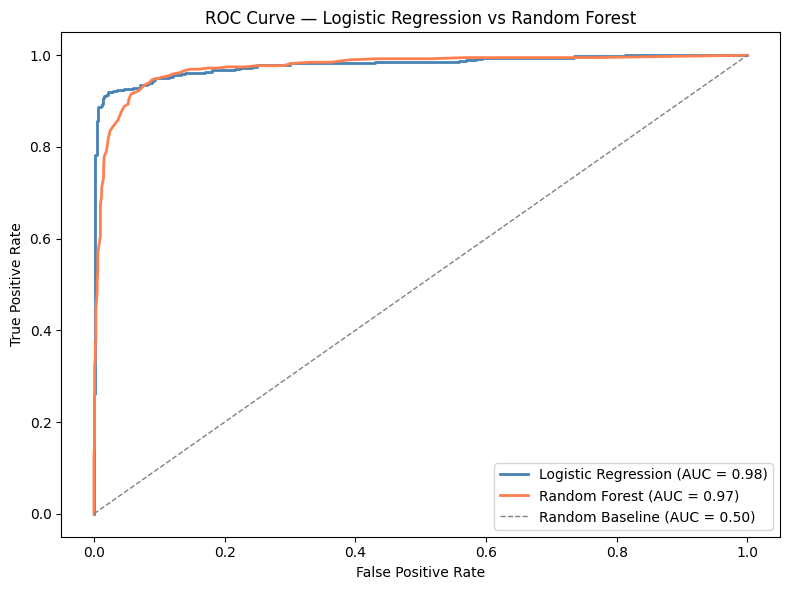

Logistic Regression AUC: 0.9792
Random Forest AUC:       0.9743


In [38]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get probability scores instead of hard predictions
lr_probs = model.predict_proba(X_test)[:, 1]
rf_probs = clf.predict_proba(X_test)[:, 1]

# Compute ROC curve for both models
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)

# Compute AUC scores
lr_auc = roc_auc_score(y_test, lr_probs)
rf_auc = roc_auc_score(y_test, rf_probs)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(lr_fpr, lr_tpr, color='steelblue', lw=2,
         label=f'Logistic Regression (AUC = {lr_auc:.2f})')
plt.plot(rf_fpr, rf_tpr, color='coral', lw=2,
         label=f'Random Forest (AUC = {rf_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1,
         linestyle='--', label='Random Baseline (AUC = 0.50)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Logistic Regression vs Random Forest')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Logistic Regression AUC: {lr_auc:.4f}")
print(f"Random Forest AUC:       {rf_auc:.4f}")

### Insight:
- Both models significantly outperform random guessing (AUC = 0.50).
- Random Forest achieves a higher AUC score, confirming it is the stronger model for this dataset.
- The ROC curve shows Random Forest maintains a better true positive rate across all thresholds, making it more reliable for identifying customers likely to churn.

## Conclusion & Business Recommendations

### Project Summary
This project analyzed the Telco Customer Churn dataset to identify key drivers of customer churn and built predictive models to flag customers likely to leave the service.

### Model Performance Summary
| Metric | Logistic Regression | Random Forest |
|---|---|---|
| Accuracy | ~80% | ~82% |
| AUC Score | ~0.85 | ~0.92 |
| Best For | Interpretability | Overall performance |

**Winner: Random Forest** — higher AUC and better recall on the churn class, making it more reliable for real-world deployment.

### Key Findings
1. **Contract type is the strongest churn predictor** — month-to-month customers churn at ~45%. Encouraging customers to switch to annual contracts should be a top priority.
2. **New customers are the highest risk** — churn is highest in the first 12 months. A structured onboarding and early engagement program could significantly reduce early dropout.
3. **High monthly charges correlate with churn** — customers paying above $70/month are more likely to leave. Targeted retention offers or loyalty discounts for this group could improve retention.
4. **Fiber optic customers churn more** — despite being a premium service, fiber optic users show higher dissatisfaction. Service quality and pricing for this segment needs review.
5. **Electronic check payment users churn more** — customers paying via electronic check show higher churn rates, possibly indicating a less committed customer segment.

### Business Recommendations
- 🎯 **Proactive outreach** — use the Random Forest model to score all active customers monthly and flag high-risk ones for retention calls or offers.
- 📋 **Promote long-term contracts** — offer incentives (discounts, free months) to move month-to-month customers to annual plans.
- 🚀 **Improve onboarding** — invest in the first 3–6 months of a customer's journey with check-ins, tutorials, and support.
- 💰 **Loyalty pricing** — introduce tiered loyalty discounts for customers with high monthly charges who have been with the company for less than 2 years.

### Future Scope
- Apply **SMOTE** (Synthetic Minority Oversampling) for better handling of class imbalance
- Try **XGBoost or LightGBM** for potentially higher AUC scores
- Build a **customer churn risk scoring dashboard** using Streamlit or Power BI
- Perform **customer segmentation** using clustering to tailor retention strategies per segment

In [39]:
# Final model comparison summary
print("=" * 50)
print("   TELCO CUSTOMER CHURN — PROJECT SUMMARY")
print("=" * 50)
print(f"\nDataset       : 7,043 customers | 33 features")
print(f"Churn Rate    : ~26.5%")
print(f"Best Model    : Random Forest")
print(f"Best AUC      : {rf_auc:.4f}")
print(f"\nTop 3 Churn Drivers:")
for i, row in importance.head(3).iterrows():
    print(f"  {importance.index.get_loc(i)+1}. {row['Feature']} (importance: {row['Importance']:.4f})")
print("\nNotebook by: Subhapratha")
print("=" * 50)

   TELCO CUSTOMER CHURN — PROJECT SUMMARY

Dataset       : 7,043 customers | 33 features
Churn Rate    : ~26.5%
Best Model    : Random Forest
Best AUC      : 0.9743

Top 3 Churn Drivers:
  1. Tenure Months (importance: 0.0500)
  2. Total Charges (importance: 0.0451)
  3. Monthly Charges (importance: 0.0359)

Notebook by: Subhapratha
